**Library Imports**

In [1]:
import re
import random
import pandas as pd
import numpy as np
import csv
from pathlib import Path

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel, BertTokenizerFast, BertForSequenceClassification

import gensim.downloader as api
from gensim.models import Word2Vec, FastText

import matplotlib.pyplot as plt
import seaborn as sns

**Set Device type**

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


**Load Dataset**

In [3]:
df = pd.read_csv('dataset/support-ticket-classification.csv')

y = np.array(df['label'].values)
unique_labels = sorted(df['label'].unique().tolist())

print(f"Dataset loaded: {df.shape}")
print(f"Classes: {unique_labels}")
print(f"Class distribution:\n{df['label'].value_counts()}\n")

Dataset loaded: (2000, 4)
Classes: ['account_access', 'billing', 'bug_report', 'refund_request', 'shipping_delivery']
Class distribution:
label
account_access       400
billing              400
refund_request       400
bug_report           400
shipping_delivery    400
Name: count, dtype: int64



**Preprocessing Steps**

In [4]:
def load_stopwords(file_path):
    stopwords = set()
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip().lower()
            if word and not word.startswith('#'):
                stopwords.add(word)
    return stopwords

stopwords = load_stopwords('dataset/stopwords.txt')

for w in ['the', 'is', 'account', 'billing', 'login', 'and', 'password']:
    print(f"{w} -> stopword: {w in stopwords}")

the -> stopword: True
is -> stopword: True
account -> stopword: False
billing -> stopword: False
login -> stopword: False
and -> stopword: True
password -> stopword: False


In [5]:
def load_exc_files(noun_file, verb_file):
    exc_map = {}
    for file_path in [noun_file, verb_file]:
        if not Path(file_path).exists():
            continue
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    exc_map[parts[0]] = parts[1]
    return exc_map

exc_map = load_exc_files('dataset/wordnet_noun.exc', 'dataset/wordnet_verb.exc')

for word in ['men', 'mice', 'geese', 'ran', 'is']:
    if word in exc_map:
        print(f"{word} -> {exc_map[word]}")

men -> man
mice -> mouse
geese -> goose
ran -> run
is -> be


In [6]:
def load_lemma_dict(file_path):
    lemma_map = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(';') or ' -> ' not in line:
                continue
            lemma_part, _, forms_part = line.partition(' -> ')
            lemma = lemma_part.split('/')[0].strip()
            for form in forms_part.split(','):
                form = form.strip()
                if form and re.match(r'^[a-z0-9]+$', form) and form not in lemma_map:
                    lemma_map[form] = lemma
    return lemma_map

lemma_map = load_lemma_dict('dataset/lemma.en.txt')
print(f"lemma_map loaded: {len(lemma_map)} entries\n")

for word in ['running', 'categories', 'responses', 'presses']:
    print(f"{word} -> {lemma_map.get(word, '(not found)')}")

lemma_map loaded: 90502 entries

running -> run
categories -> category
responses -> response
presses -> press


In [7]:
CONTRACTIONS = {
    "can't": "cannot", "won't": "will not", "don't": "do not",
    "doesn't": "does not", "didn't": "did not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "you're": "you are", "we're": "we are",
    "they're": "they are", "it's": "it is", "that's": "that is",
    "there's": "there is", "i've": "i have", "we've": "we have",
    "they've": "they have", "shouldn't": "should not", "couldn't": "could not",
    "wouldn't": "would not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not",
}

for k, v in list(CONTRACTIONS.items())[:3]:
    print(f"{k} -> {v}")

can't -> cannot
won't -> will not
don't -> do not


In [8]:
DOMAIN_PHRASE_MAP = {
    "log in": "login", "sign in": "login",
    "wireless": "wifi", "wifi": "wifi",
    "remote access": "vpn", "vpn": "vpn",
    "mfa": "mfa", "2fa": "mfa",
}

DOMAIN_TOKEN_MAP = {
    "pls": "please", "plz": "please", "asap": "urgent",
    "u": "you", "ur": "your", "pwd": "password",
    "acct": "account", "acc": "account", "auth": "authentication",
    "db": "database", "srv": "server", "msg": "message",
    "req": "request", "otp": "onetimepassword", "2fa": "mfa",
}

for k, v in list(DOMAIN_PHRASE_MAP.items())[:3]:
    print(f"phrase  {k} -> {v}")
for k, v in list(DOMAIN_TOKEN_MAP.items())[:3]:
    print(f"token   {k} -> {v}")

phrase  log in -> login
phrase  sign in -> login
phrase  wireless -> wifi
token   pls -> please
token   plz -> please
token   asap -> urgent


In [9]:
NEGATION_TOKENS = {"no", "not", "never", "cannot", "failed", "unable", "without"}
DOMAIN_STOPWORDS = {"hi", "hello", "dear", "team", "please", "kindly", "thanks", "thank", "regards", "best", "sir", "madam"}
ALLOWED_TOKEN_PUNCT = set(".-/@#+_:\\")

for w in ['cannot', 'not', 'hello', 'billing', 'please', 'account']:
    print(f"{w}  negation={w in NEGATION_TOKENS}  stopword={w in DOMAIN_STOPWORDS}")

cannot  negation=True  stopword=False
not  negation=True  stopword=False
hello  negation=False  stopword=True
billing  negation=False  stopword=False
please  negation=False  stopword=True
account  negation=False  stopword=False


In [10]:
REPLY_CHAIN_PATTERN = re.compile(r"^\s*on\s+.+\s+wrote:\s*$", flags=re.IGNORECASE)
HEADER_PATTERN = re.compile(r"^\s*(from|sent|to|cc|bcc|date)\s*:", flags=re.IGNORECASE)
SIGNATURE_PATTERN = re.compile(
    r"^\s*(thanks|thank you|regards|best regards|kind regards|sincerely|cheers)[\s,!.-]*$",
    flags=re.IGNORECASE,
)
DISCLAIMER_PATTERN = re.compile(
    r"(this\s+(e-?mail|message).{0,120}(confidential|intended only)|please\s+do\s+not\s+reply|"
    r"automatically\s+generated|auto-?generated)",
    flags=re.IGNORECASE,
)

samples = [
    ("On Mon Apr 12 user@x.com wrote:", REPLY_CHAIN_PATTERN, "reply_chain"),
    ("From: user@example.com",          HEADER_PATTERN,      "header"),
    ("Thanks,",                          SIGNATURE_PATTERN,   "signature"),
    ("This email is auto-generated",     DISCLAIMER_PATTERN,  "disclaimer"),
]
for text, pattern, label in samples:
    print(f"{label} {'✓' if pattern.search(text) else '✗'}  {text}")

reply_chain ✓  On Mon Apr 12 user@x.com wrote:
header ✓  From: user@example.com
signature ✓  Thanks,
disclaimer ✓  This email is auto-generated


In [11]:
ENTITY_TAG_PATTERNS = [
    ("IP_ADDR",    re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b")),
    ("TICKET_ID",  re.compile(r"\b(?:inc|ticket|case|ref|req)[-_:#\s]*\d{3,}\b", flags=re.IGNORECASE)),
    ("ORDER_ID",   re.compile(r"\b(?:order|ord)[-_:#\s]*\d{3,}\b", flags=re.IGNORECASE)),
    ("VERSION",    re.compile(r"\bv\d+(?:\.\d+){1,3}\b", flags=re.IGNORECASE)),
    ("ERROR_CODE", re.compile(r"\b(?:0x[a-fA-F0-9]{4,}|(?:error|err|errno|exception)[-_:#\s]*[a-z0-9_-]{2,})\b", flags=re.IGNORECASE)),
    ("LONG_NUM",   re.compile(r"\b\d{6,}\b")),
]

TOKEN_PATTERN = re.compile(
    r"(?:https?://\S+|www\.\S+)|"
    r"(?:[A-Za-z]:\\[^\s]+)|"
    r"(?:[\w.+-]+@[\w.-]+\.\w+)|"
    r"(?:\b\w+(?:[._:/\\#@+-]\w+)+\b)|"
    r"(?:\b\w+\b)"
)

sample = "Error 0x1234ABCD on ticket INC-5432 from 192.168.1.1, order 98765, v1.2.3"
for tag, pattern in ENTITY_TAG_PATTERNS:
    m = pattern.search(sample)
    if m:
        print(f"{tag} matched: {m.group(0)}")

IP_ADDR matched: 192.168.1.1
TICKET_ID matched: INC-5432
ORDER_ID matched: order 98765
VERSION matched: v1.2.3
ERROR_CODE matched: Error 0x1234ABCD


In [12]:
def normalize_whitespace(text, keep_newlines=False):
    if keep_newlines:
        text = re.sub(r"[^\S\n]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        return text.strip()
    return re.sub(r"\s+", " ", text).strip()

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = text.replace("\u200b", " ")
    text = re.sub(r"[\t\f\v]+", " ", text)
    return normalize_whitespace(text, keep_newlines=True)

def remove_boilerplate(text):
    lines = [line.strip() for line in text.split("\n")]
    kept_lines = []
    for idx, line in enumerate(lines):
        if not line:
            continue
        if REPLY_CHAIN_PATTERN.match(line):
            break
        if HEADER_PATTERN.match(line):
            continue
        if DISCLAIMER_PATTERN.search(line):
            continue
        if SIGNATURE_PATTERN.match(line) and idx >= max(2, len(lines) // 3):
            break
        kept_lines.append(line)
    return normalize_whitespace("\n".join(kept_lines))

sample_email = "From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\nOn Mon Apr 12 support@company.com wrote:\n> Previous message here."
print("raw   :", repr(sample_email[:80]))
print("clean :", repr(clean_text(sample_email)[:80]))
print("boiler:", repr(remove_boilerplate(clean_text(sample_email))[:80]))

raw   : 'From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\n'
clean : 'From: user@example.com\nDate: Mon Apr 12\n\nI cannot login to my account.\n\nThanks\n\n'
boiler: 'I cannot login to my account.'


In [13]:
def expand_contractions(text):
    for contraction, expanded in CONTRACTIONS.items():
        text = re.sub(rf"\b{re.escape(contraction)}\b", expanded, text, flags=re.IGNORECASE)
    return text

def apply_domain_mapping(text, phrase_map=None):
    phrase_map = phrase_map or DOMAIN_PHRASE_MAP
    for source, target in phrase_map.items():
        text = re.sub(rf"\b{re.escape(source)}\b", target, text, flags=re.IGNORECASE)
    return text

samples = [
    "I can't log in with 2fa",
    "Won't connect over wireless",
    "Please sign in using remote access",
]
for s in samples:
    print(f"{s} -> {apply_domain_mapping(expand_contractions(s))}")

I can't log in with 2fa -> I cannot login with mfa
Won't connect over wireless -> will not connect over wifi
Please sign in using remote access -> Please login using vpn


In [14]:
def normalize_entities(text, add_tags=True):
    if not add_tags:
        return text
    for tag, pattern in ENTITY_TAG_PATTERNS:
        text = pattern.sub(lambda m: f" {m.group(0)} {tag} ", text)
    return normalize_whitespace(text)

def tokenize(text):
    return TOKEN_PATTERN.findall(text)

def normalize_token(token, lowercase=True):
    token = token.strip("\"'`()[]{}<> ").strip(".,;!?")
    if not token:
        return ""
    if token.isalpha():
        token = re.sub(r"(.)\1{2,}", r"\1\1", token)
    mapped = DOMAIN_TOKEN_MAP.get(token.lower())
    if mapped is not None:
        return mapped
    return token.lower() if lowercase else token

def is_identifier_like(token):
    if not token:
        return False
    if token.isupper() and len(token) > 1:
        return True
    if any(ch.isdigit() for ch in token):
        return True
    if any(ch in ALLOWED_TOKEN_PUNCT for ch in token):
        return True
    return False

sample = "Error 0x1234ABCD on ticket INC-5432 from 192.168.1.1, pls fix asap"
print("entities :", normalize_entities(sample))
print("tokens   :", tokenize(sample)[:8])
print("normed   :", [normalize_token(t) for t in tokenize(sample)[:6]])

entities : Error 0x1234ABCD ERROR_CODE on ticket INC-5432 TICKET_ID from 192.168.1.1 IP_ADDR , pls fix asap
tokens   : ['Error', '0x1234ABCD', 'on', 'ticket', 'INC-5432', 'from', '192.168.1.1', 'pls']
normed   : ['error', '0x1234abcd', 'on', 'ticket', 'inc-5432', 'from']


In [15]:
def should_lemmatize(token):
    if token in NEGATION_TOKENS:
        return False
    if not token.isalpha() or len(token) < 4:
        return False
    if is_identifier_like(token):
        return False
    if token.endswith(("ing", "ed")):
        return False
    return True

def postprocess_tokens(tokens, lemma_map=None, exc_map=None, remove_stopwords=True, stopwords=None):
    if stopwords is None:
        stopwords = set()
    processed = []
    for token in tokens:
        token = normalize_token(token, lowercase=True)
        if len(token) <= 1:
            continue
        if remove_stopwords and token in stopwords and token not in NEGATION_TOKENS:
            continue
        if should_lemmatize(token):
            lemma = exc_map.get(token) if exc_map else None
            if lemma is None and lemma_map:
                lemma = lemma_map.get(token)
            if lemma:
                token = lemma
        if remove_stopwords and token in stopwords and token not in NEGATION_TOKENS:
            continue
        processed.append(token)
    return processed

tokens = ['running', 'accounts', 'the', 'categories', 'pls', 'cannot', 'responses']
result = postprocess_tokens(tokens, lemma_map=lemma_map, exc_map=exc_map, remove_stopwords=True, stopwords=DOMAIN_STOPWORDS)
print(f"before : {tokens}")
print(f"after  : {result}")

before : ['running', 'accounts', 'the', 'categories', 'pls', 'cannot', 'responses']
after  : ['running', 'account', 'the', 'category', 'cannot', 'response']


In [16]:
def preprocess_for_bert(text):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=False)
    text = normalize_whitespace(text)
    text = text.lower()
    return text

def preprocess_for_tfidf(text, lemma_map=None, exc_map=None):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=True)
    tokens = tokenize(text)
    tokens = postprocess_tokens(tokens, lemma_map=lemma_map, exc_map=exc_map, remove_stopwords=True, stopwords=DOMAIN_STOPWORDS)
    return " ".join(tokens)

def preprocess_for_embedding(text):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=False)
    tokens = tokenize(text)
    tokens = postprocess_tokens(tokens, lemma_map=None, exc_map=None, remove_stopwords=False, stopwords=set())
    return " ".join(tokens)

sample = "SUBJECT: Can't login to account BODY: I'm trying to sign in but getting error 0x401 on ticket INC-9921"
print(f"raw    : {sample}")
print(f"bert   : {preprocess_for_bert(sample)}")
print(f"tfidf  : {preprocess_for_tfidf(sample, lemma_map=lemma_map, exc_map=exc_map)}")
print(f"embed  : {preprocess_for_embedding(sample)}")

raw    : SUBJECT: Can't login to account BODY: I'm trying to sign in but getting error 0x401 on ticket INC-9921
bert   : subject: cannot login to account body: i am trying to login but getting error 0x401 on ticket inc-9921
tfidf  : subject cannot login to account body am trying to login but getting error 0x401 error_code on ticket inc-9921 ticket_id
embed  : subject cannot login to account body am trying to login but getting error 0x401 on ticket inc-9921


In [17]:
def compose_ticket_text(subject, text):
    subject = "" if pd.isna(subject) else str(subject).strip()
    text = "" if pd.isna(text) else str(text).strip()
    return f"SUBJECT: {subject} BODY: {text}".strip()

raw_texts, bert_texts, tfidf_texts, embedding_texts = [], [], [], []

for idx in range(len(df)):
    raw = compose_ticket_text(df.iloc[idx]['subject'], df.iloc[idx]['text'])
    raw_texts.append(raw)
    bert_texts.append(preprocess_for_bert(raw))
    tfidf_texts.append(preprocess_for_tfidf(raw, lemma_map=lemma_map, exc_map=exc_map))
    embedding_texts.append(preprocess_for_embedding(raw))

df['raw_text']       = raw_texts
df['bert_text']      = bert_texts
df['tfidf_text']     = tfidf_texts
df['embedding_text'] = embedding_texts

x_train, x_test, y_train, y_test = train_test_split(
    np.arange(len(df)), y, test_size=0.25, stratify=y,
)

print(f"Train: {len(x_train)} samples  |  Test: {len(x_test)} samples\n")

sample_idx = x_train[0]
print(f"raw   : {df.iloc[sample_idx]['raw_text'][:120]}")
print(f"bert  : {df.iloc[sample_idx]['bert_text'][:120]}")
print(f"tfidf : {df.iloc[sample_idx]['tfidf_text'][:120]}")
print(f"embed : {df.iloc[sample_idx]['embedding_text'][:120]}")

Train: 1500 samples  |  Test: 500 samples

raw   : SUBJECT: Duplicate accounts created BODY: I accidentally created two accounts and now I have duplicates I can't merge.
bert  : subject: duplicate accounts created body: i accidentally created two accounts and now i have duplicates i cannot merge.
tfidf : subject duplicate account created body accidentally created two account and now have duplicate cannot merge
embed : subject duplicate accounts created body accidentally created two accounts and now have duplicates cannot merge


**TF-IDF Training Step**

In [18]:
class TFIDFExtractor:
    def __init__(self, word_max=35000, char_max=20000):
        self.word_max = word_max
        self.char_max = char_max
        self.word_vec = TfidfVectorizer(
            lowercase=True, analyzer='word', ngram_range=(1, 2),
            min_df=2, max_df=0.95, sublinear_tf=True,
            strip_accents='unicode', max_features=word_max
        )
        self.char_vec = TfidfVectorizer(
            lowercase=True, analyzer='char_wb', ngram_range=(3, 5),
            min_df=2, sublinear_tf=True, max_features=char_max
        )
    
    def fit(self, texts):
        self.word_vec.fit(texts)
        self.char_vec.fit(texts)
        return self
    
    def transform(self, texts):
        X_word = self.word_vec.transform(texts)
        X_char = self.char_vec.transform(texts)
        return hstack([X_word, X_char]).tocsr()

In [19]:
train_texts_prep = df.iloc[x_train]['tfidf_text'].values
test_texts_prep = df.iloc[x_test]['tfidf_text'].values
train_texts_raw = df.iloc[x_train]['raw_text'].values
test_texts_raw = df.iloc[x_test]['raw_text'].values

extractor_prep = TFIDFExtractor(word_max=35000, char_max=20000)
extractor_prep.fit(train_texts_prep)
X_train_tfidf_prep = extractor_prep.transform(train_texts_prep)
X_test_tfidf_prep = extractor_prep.transform(test_texts_prep)

extractor_raw = TFIDFExtractor(word_max=35000, char_max=20000)
extractor_raw.fit(train_texts_raw)
X_train_tfidf_raw = extractor_raw.transform(train_texts_raw)
X_test_tfidf_raw = extractor_raw.transform(test_texts_raw)

print(f"Preprocessed TF-IDF: {X_train_tfidf_prep.shape} (train), {X_test_tfidf_prep.shape} (test)")
print(f"Raw TF-IDF:         {X_train_tfidf_raw.shape} (train), {X_test_tfidf_raw.shape} (test)")

Preprocessed TF-IDF: (1500, 19878) (train), (500, 19878) (test)
Raw TF-IDF:         (1500, 22529) (train), (500, 22529) (test)


In [20]:
results_raw = {}

print("TF-IDF (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_tfidf_raw, y_train)
    y_pred = clf.predict(X_test_tfidf_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_raw[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

TF-IDF (Raw)

SVM                       Accuracy: 0.9280
Logistic Regression       Accuracy: 0.9220
KNN                       Accuracy: 0.9200


In [21]:
results_prep = {}

print("TF-IDF (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_tfidf_prep, y_train)
    y_pred = clf.predict(X_test_tfidf_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

TF-IDF (Preprocessed)

SVM                       Accuracy: 0.9260
Logistic Regression       Accuracy: 0.9260
KNN                       Accuracy: 0.9100


**Word2Vec**

In [22]:
def scale_dense_features(X_train, X_test):
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test)

def get_avg_embedding(text, keyed_vectors, vector_size):
    words = text.split()
    vectors = [keyed_vectors[word] for word in words if word in keyed_vectors]
    if not vectors:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0)

def build_embedding_feature_pair(df, train_idx, test_idx, keyed_vectors, vector_size, prep_col='embedding_text', raw_col='raw_text'):
    X_train_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_prep = np.array([get_avg_embedding(df.iloc[i][prep_col], keyed_vectors, vector_size) for i in test_idx])
    X_train_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in train_idx])
    X_test_raw = np.array([get_avg_embedding(df.iloc[i][raw_col], keyed_vectors, vector_size) for i in test_idx])

    X_train_prep, X_test_prep = scale_dense_features(X_train_prep, X_test_prep)
    X_train_raw, X_test_raw = scale_dense_features(X_train_raw, X_test_raw)
    return X_train_prep, X_test_prep, X_train_raw, X_test_raw

def train_local_word2vec(sentences, vector_size=300, epochs=45):
    local_model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=5,
        min_count=1,
        sg=1,
        workers=4,
        epochs=epochs,
    )
    return local_model.wv

print("Loading pretrained Word2Vec (Google News 300d)...")
train_sentences_embedding = [df.iloc[i]['embedding_text'].split() for i in x_train]
try:
    w2v_vectors = api.load("word2vec-google-news-300")
    w2v_dim = w2v_vectors.vector_size
    print(f"Pretrained Word2Vec loaded: {w2v_dim}-dimensional")
except Exception as ex:
    print(f"Pretrained Word2Vec unavailable ({ex}). Training local fallback model...")
    w2v_vectors = train_local_word2vec(train_sentences_embedding, vector_size=300, epochs=55)
    w2v_dim = w2v_vectors.vector_size
    print(f"Local Word2Vec trained: {w2v_dim}-dimensional")

Loading pretrained Word2Vec (Google News 300d)...
Pretrained Word2Vec loaded: 300-dimensional


In [23]:
print("Creating Word2Vec vectors for preprocessed and raw text...")
X_train_embed_prep, X_test_embed_prep, X_train_embed_raw, X_test_embed_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    w2v_vectors,
    w2v_dim,
    prep_col='embedding_text',
    raw_col='raw_text',
)

print(f"Word2Vec (Preprocessed): {X_train_embed_prep.shape} (train), {X_test_embed_prep.shape} (test)")
print(f"Word2Vec (Raw):         {X_train_embed_raw.shape} (train), {X_test_embed_raw.shape} (test)")

Creating Word2Vec vectors for preprocessed and raw text...
Word2Vec (Preprocessed): (1500, 300) (train), (500, 300) (test)
Word2Vec (Raw):         (1500, 300) (train), (500, 300) (test)


In [24]:
results_embed_raw = {}

print("Word2Vec (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_raw, y_train)
    y_pred = clf.predict(X_test_embed_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_embed_raw[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

Word2Vec (Raw)

SVM                       Accuracy: 0.8940
Logistic Regression       Accuracy: 0.8780
KNN                       Accuracy: 0.8520


In [25]:
results_embed_prep = {}

print("Word2Vec (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_prep, y_train)
    y_pred = clf.predict(X_test_embed_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_embed_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

Word2Vec (Preprocessed)

SVM                       Accuracy: 0.8920
Logistic Regression       Accuracy: 0.8880
KNN                       Accuracy: 0.8900


**FastText**

In [26]:
def preprocess_for_fasttext(text):
    text = clean_text(text)
    text = remove_boilerplate(text)
    text = expand_contractions(text)
    text = apply_domain_mapping(text)
    text = normalize_entities(text, add_tags=False)
    tokens = tokenize(text)
    tokens = postprocess_tokens(tokens, lemma_map=None, exc_map=None, remove_stopwords=False, stopwords=set())
    return " ".join(tokens)

fasttext_prep_texts = []
for idx in range(len(df)):
    raw = compose_ticket_text(df.iloc[idx]['subject'], df.iloc[idx]['text'])
    fasttext_prep_texts.append(preprocess_for_fasttext(raw))

df['fasttext_text'] = fasttext_prep_texts

print(f"Added fasttext_text column")
sample_idx = x_train[0]
print(f"raw      : {df.iloc[sample_idx]['raw_text'][:100]}")
print(f"fasttext : {df.iloc[sample_idx]['fasttext_text'][:100]}")

Added fasttext_text column
raw      : SUBJECT: Duplicate accounts created BODY: I accidentally created two accounts and now I have duplica
fasttext : subject duplicate accounts created body accidentally created two accounts and now have duplicates ca


In [27]:
print("Training FastText embeddings (subword-aware)...")

train_sentences_fasttext_prep = [df.iloc[i]['fasttext_text'].split() for i in x_train]
train_sentences_fasttext_raw = [df.iloc[i]['raw_text'].lower().split() for i in x_train]

fasttext_prep = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
)
fasttext_prep.build_vocab(train_sentences_fasttext_prep)
fasttext_prep.train(train_sentences_fasttext_prep, total_examples=len(train_sentences_fasttext_prep), epochs=55)

fasttext_raw = FastText(
    vector_size=220,
    window=5,
    min_count=1,
    sg=1,
    min_n=3,
    max_n=6,
    workers=4,
)
fasttext_raw.build_vocab(train_sentences_fasttext_raw)
fasttext_raw.train(train_sentences_fasttext_raw, total_examples=len(train_sentences_fasttext_raw), epochs=55)

print("Creating FastText vectors for preprocessed and raw text...")
X_train_embed_ft_prep, X_test_embed_ft_prep, X_train_embed_ft_raw, X_test_embed_ft_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    fasttext_prep.wv,
    fasttext_prep.vector_size,
    prep_col='fasttext_text',
    raw_col='raw_text',
)

print(f"FastText (Preprocessed): {X_train_embed_ft_prep.shape} (train), {X_test_embed_ft_prep.shape} (test)")
print(f"FastText (Raw):         {X_train_embed_ft_raw.shape} (train), {X_test_embed_ft_raw.shape} (test)")

Training FastText embeddings (subword-aware)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Creating FastText vectors for preprocessed and raw text...
FastText (Preprocessed): (1500, 220) (train), (500, 220) (test)
FastText (Raw):         (1500, 220) (train), (500, 220) (test)


In [28]:
results_ft_raw = {}

print("FastText (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_ft_raw, y_train)
    y_pred = clf.predict(X_test_embed_ft_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_ft_raw[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

FastText (Raw)

SVM                       Accuracy: 0.9200
Logistic Regression       Accuracy: 0.8800
KNN                       Accuracy: 0.8980


In [29]:
results_ft_prep = {}

print("FastText (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_ft_prep, y_train)
    y_pred = clf.predict(X_test_embed_ft_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_ft_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

FastText (Preprocessed)

SVM                       Accuracy: 0.9180
Logistic Regression       Accuracy: 0.8680
KNN                       Accuracy: 0.8900


**GloVe**

In [30]:
print("Loading pretrained GloVe (glove-wiki-gigaword-100)...")

train_sentences_glove = [df.iloc[i]['embedding_text'].split() for i in x_train]
train_sentences_glove += [df.iloc[i]['raw_text'].lower().split() for i in x_train]

try:
    glove_vectors = api.load("glove-wiki-gigaword-100")
    glove_dim = glove_vectors.vector_size
    print(f"Pretrained GloVe loaded: {glove_dim}-dimensional")
except Exception as ex:
    print(f"Pretrained GloVe unavailable ({ex}). Training local fallback vectors...")
    glove_vectors = train_local_word2vec(train_sentences_glove, vector_size=100, epochs=45)
    glove_dim = glove_vectors.vector_size
    print(f"Local fallback vectors trained: {glove_dim}-dimensional")

print("Creating GloVe vectors for preprocessed and raw text...")
X_train_glove_prep, X_test_glove_prep, X_train_glove_raw, X_test_glove_raw = build_embedding_feature_pair(
    df,
    x_train,
    x_test,
    glove_vectors,
    glove_dim,
    prep_col='embedding_text',
    raw_col='raw_text',
)

print(f"GloVe (Preprocessed): {X_train_glove_prep.shape} (train), {X_test_glove_prep.shape} (test)")
print(f"GloVe (Raw):         {X_train_glove_raw.shape} (train), {X_test_glove_raw.shape} (test)")

results_glove_raw = {}
results_glove_prep = {}

print("GloVe (Raw)\n")
for clf_name, clf in [('SVM', SVC(kernel='rbf')),
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_glove_raw, y_train)
    y_pred = clf.predict(X_test_glove_raw)

    accuracy = accuracy_score(y_test, y_pred)
    results_glove_raw[clf_name] = {'accuracy': accuracy}

    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

print("\nGloVe (Preprocessed)\n")
for clf_name, clf in [('SVM', SVC(kernel='rbf')),
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_glove_prep, y_train)
    y_pred = clf.predict(X_test_glove_prep)

    accuracy = accuracy_score(y_test, y_pred)
    results_glove_prep[clf_name] = {'accuracy': accuracy}

    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

Loading pretrained GloVe (glove-wiki-gigaword-100)...
Pretrained GloVe loaded: 100-dimensional
Creating GloVe vectors for preprocessed and raw text...
GloVe (Preprocessed): (1500, 100) (train), (500, 100) (test)
GloVe (Raw):         (1500, 100) (train), (500, 100) (test)
GloVe (Raw)

SVM                       Accuracy: 0.8440
Logistic Regression       Accuracy: 0.8240
KNN                       Accuracy: 0.8240

GloVe (Preprocessed)

SVM                       Accuracy: 0.8800
Logistic Regression       Accuracy: 0.8180
KNN                       Accuracy: 0.8520


**Bert**

In [31]:
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(device)
bert_model.eval()

bert_batch_size = 24 if device.type == 'cuda' else 10
bert_max_length = 192

print(f"BERT loaded (output dimension: 768, batch_size={bert_batch_size}, max_length={bert_max_length})")

def extract_bert_features(texts, tokenizer, model, device, batch_size=16, max_length=192):
    features = []
    
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            
            encodings = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors='pt'
            )
            
            input_ids = encodings['input_ids'].to(device)
            attention_mask = encodings['attention_mask'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            token_embeddings = outputs.last_hidden_state
            mask_expanded = attention_mask.unsqueeze(-1).float()
            sum_embeddings = (token_embeddings * mask_expanded).sum(dim=1)
            sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
            batch_features = (sum_embeddings / sum_mask).cpu().numpy()
            features.extend(batch_features)
    
    return np.array(features)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded (output dimension: 768, batch_size=10, max_length=192)


In [32]:
print("Extracting BERT features from preprocessed text...")
train_texts_bert_prep = df.iloc[x_train]['bert_text'].tolist()
test_texts_bert_prep = df.iloc[x_test]['bert_text'].tolist()
X_train_embed_bert_prep = extract_bert_features(
    train_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_test_embed_bert_prep = extract_bert_features(
    test_texts_bert_prep, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_train_embed_bert_prep, X_test_embed_bert_prep = scale_dense_features(X_train_embed_bert_prep, X_test_embed_bert_prep)

print("Extracting BERT features from raw text...")
train_texts_bert_raw = df.iloc[x_train]['raw_text'].tolist()
test_texts_bert_raw = df.iloc[x_test]['raw_text'].tolist()
X_train_embed_bert_raw = extract_bert_features(
    train_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_test_embed_bert_raw = extract_bert_features(
    test_texts_bert_raw, tokenizer_bert, bert_model, device, batch_size=bert_batch_size, max_length=bert_max_length
)
X_train_embed_bert_raw, X_test_embed_bert_raw = scale_dense_features(X_train_embed_bert_raw, X_test_embed_bert_raw)

print(f"BERT (Preprocessed): {X_train_embed_bert_prep.shape} (train), {X_test_embed_bert_prep.shape} (test)")
print(f"BERT (Raw):         {X_train_embed_bert_raw.shape} (train), {X_test_embed_bert_raw.shape} (test)")

Extracting BERT features from preprocessed text...
Extracting BERT features from raw text...
BERT (Preprocessed): (1500, 768) (train), (500, 768) (test)
BERT (Raw):         (1500, 768) (train), (500, 768) (test)


In [33]:
results_bert_raw = {}

print("BERT (Raw)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_bert_raw, y_train)
    y_pred = clf.predict(X_test_embed_bert_raw)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_bert_raw[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

BERT (Raw)

SVM                       Accuracy: 0.8960
Logistic Regression       Accuracy: 0.8900
KNN                       Accuracy: 0.8840


In [34]:
results_bert_prep = {}

print("BERT (Preprocessed)\n")

for clf_name, clf in [('SVM', SVC(kernel='rbf')), 
                       ('Logistic Regression', LogisticRegression(max_iter=1000)),
                       ('KNN', KNeighborsClassifier(n_neighbors=5))]:
    clf.fit(X_train_embed_bert_prep, y_train)
    y_pred = clf.predict(X_test_embed_bert_prep)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    results_bert_prep[clf_name] = {'accuracy': accuracy}
    
    print(f"{clf_name:<25} Accuracy: {accuracy:.4f}")

BERT (Preprocessed)

SVM                       Accuracy: 0.8980
Logistic Regression       Accuracy: 0.8900
KNN                       Accuracy: 0.8800


**BERT (Fine-tuned)**

In [35]:
label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

bert_train_idx = x_train
bert_test_idx = x_test
bert_text_column = 'bert_text'

train_texts_bert = df.iloc[bert_train_idx][bert_text_column].tolist()
test_texts_bert = df.iloc[bert_test_idx][bert_text_column].tolist()

y_train_bert = np.array([label_to_id[label] for label in y[bert_train_idx]], dtype=np.int64)
y_test_bert = np.array([label_to_id[label] for label in y[bert_test_idx]], dtype=np.int64)

class TicketDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=192):
        self.texts = texts
        self.labels = labels
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx], dtype=torch.long) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def run_bert_inference(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    eval_loss = 0.0

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            eval_loss += outputs.loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(batch['labels'].detach().cpu().numpy())

    mean_loss = eval_loss / max(1, len(data_loader))
    return np.array(all_preds), np.array(all_labels), mean_loss

bert_tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(unique_labels),
)
bert_model.to(device)

bert_batch_size = 16 if device.type == 'cuda' else 8
bert_epochs = 3
bert_lr = 2e-5
bert_max_length = 192

train_dataset_bert = TicketDataset(train_texts_bert, y_train_bert, bert_tokenizer, max_length=bert_max_length)
test_dataset_bert = TicketDataset(test_texts_bert, y_test_bert, bert_tokenizer, max_length=bert_max_length)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=bert_batch_size, shuffle=True)
test_loader_bert = DataLoader(test_dataset_bert, batch_size=bert_batch_size, shuffle=False)

optimizer_bert = Adam(bert_model.parameters(), lr=bert_lr)

print(f"Fine-tuning BERT on {len(train_dataset_bert)} train samples...")
for epoch in range(bert_epochs):
    bert_model.train()
    train_loss = 0.0

    for batch in train_loader_bert:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**batch)
        loss = outputs.loss

        optimizer_bert.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer_bert.step()

        train_loss += loss.item()

    mean_train_loss = train_loss / max(1, len(train_loader_bert))
    print(f"Epoch {epoch + 1}/{bert_epochs} | Train Loss: {mean_train_loss:.4f}")

test_preds_ids, test_true_ids, test_loss = run_bert_inference(bert_model, test_loader_bert, device)
bert_test_preds = np.array([id_to_label[idx] for idx in test_preds_ids])
bert_test_true = np.array([id_to_label[idx] for idx in test_true_ids])

bert_accuracy = accuracy_score(bert_test_true, bert_test_preds)

precision_cls, recall_cls, f1_cls, support_cls = precision_recall_fscore_support(
    bert_test_true,
    bert_test_preds,
    labels=unique_labels,
    zero_division=0,
 )

bert_class_metrics = pd.DataFrame({
    'class': unique_labels,
    'precision': precision_cls,
    'recall': recall_cls,
    'f1': f1_cls,
    'support': support_cls,
})

results_bert = {
    'BERT': {
        'accuracy': bert_accuracy,
    }
}

print(f"BERT (Fine-tuned) Test Loss: {test_loss:.4f}")
print(f"BERT (Fine-tuned) Accuracy: {bert_accuracy:.4f}")
bert_class_metrics

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning BERT on 1500 train samples...
Epoch 1/3 | Train Loss: 0.7703
Epoch 2/3 | Train Loss: 0.2165
Epoch 3/3 | Train Loss: 0.1244
BERT (Fine-tuned) Test Loss: 0.2870
BERT (Fine-tuned) Accuracy: 0.9340


,class,precision,recall,f1,support
0,account_access,0.898148,0.97,0.932692,100
1,billing,0.948980,0.93,0.939394,100
2,bug_report,0.956044,0.87,0.910995,100
3,refund_request,0.969072,0.94,0.954315,100
4,shipping_delivery,0.905660,0.96,0.932039,100


In [36]:
feature_methods = [
    'TF-IDF (Raw)',
    'TF-IDF (Preprocessed)',

    'Word2Vec (Raw)',
    'Word2Vec (Preprocessed)',
    
    'FastText (Raw)',
    'FastText (Preprocessed)',
    
    'GloVe (Raw)',
    'GloVe (Preprocessed)',

    'BERT (Raw)',
    'BERT (Preprocessed)',
]

all_results = {
    'TF-IDF (Preprocessed)': results_prep,
    'TF-IDF (Raw)': results_raw,
    'Word2Vec (Preprocessed)': results_embed_prep,
    'Word2Vec (Raw)': results_embed_raw,
    'FastText (Preprocessed)': results_ft_prep,
    'FastText (Raw)': results_ft_raw,
    'GloVe (Preprocessed)': results_glove_prep,
    'GloVe (Raw)': results_glove_raw,
    'BERT (Preprocessed)': results_bert_prep,
    'BERT (Raw)': results_bert_raw,
    'BERT (Fine-tuned)': results_bert_prep,
}

records = []
for method_name, model_scores in all_results.items():
    for model_name, metrics in model_scores.items():
        accuracy = metrics['accuracy']
        records.append({
            'Method': method_name,
            'Model': model_name,
            'Accuracy': accuracy,
        })

results_df = pd.DataFrame(records)
accuracy_df = results_df.pivot(index='Method', columns='Model', values='Accuracy')

ordered_methods = [method for method in feature_methods if method in accuracy_df.index]
if 'BERT (Fine-tuned)' in accuracy_df.index:
    ordered_methods.append('BERT (Fine-tuned)')

accuracy_df = accuracy_df.reindex(ordered_methods)

accuracy_df

Model,KNN,Logistic Regression,SVM
Method,,,
TF-IDF (Raw),0.920,0.922,0.928
TF-IDF (Preprocessed),0.910,0.926,0.926
Word2Vec (Raw),0.852,0.878,0.894
Word2Vec (Preprocessed),0.890,0.888,0.892
FastText (Raw),0.898,0.880,0.920
FastText (Preprocessed),0.890,0.868,0.918
GloVe (Raw),0.824,0.824,0.844
GloVe (Preprocessed),0.852,0.818,0.880
BERT (Raw),0.884,0.890,0.896


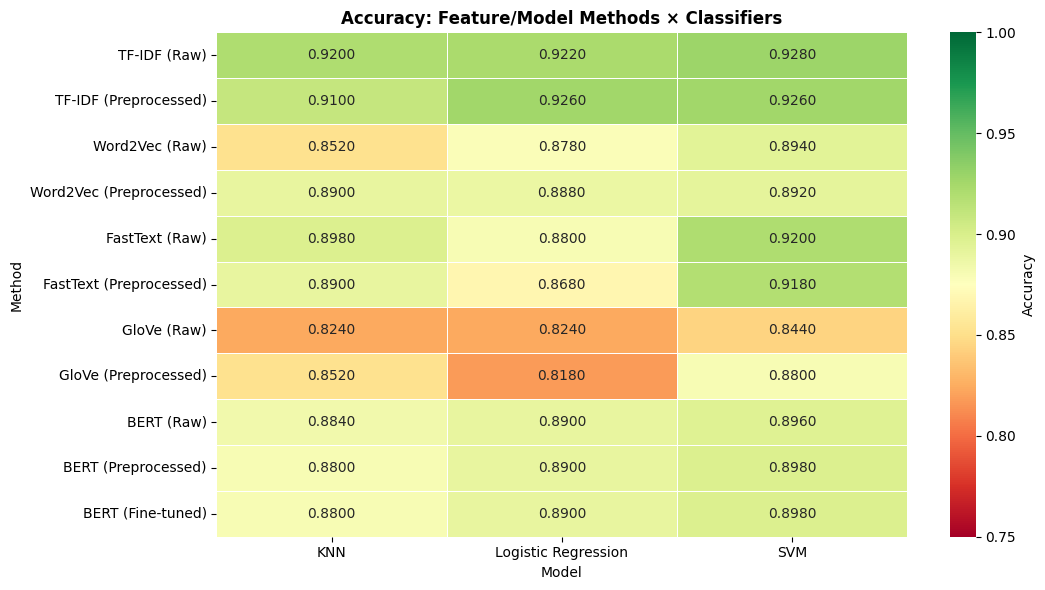

In [37]:
plt.figure(figsize=(11, 6))
sns.heatmap(
    accuracy_df,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    mask=accuracy_df.isna(),
    cbar_kws={'label': 'Accuracy'},
    vmin=0.75,
    vmax=1.00,
    linewidths=0.5,
    linecolor='white',
)
plt.title('Accuracy: Feature/Model Methods × Classifiers', fontsize=12, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Method')
plt.tight_layout()
plt.show()

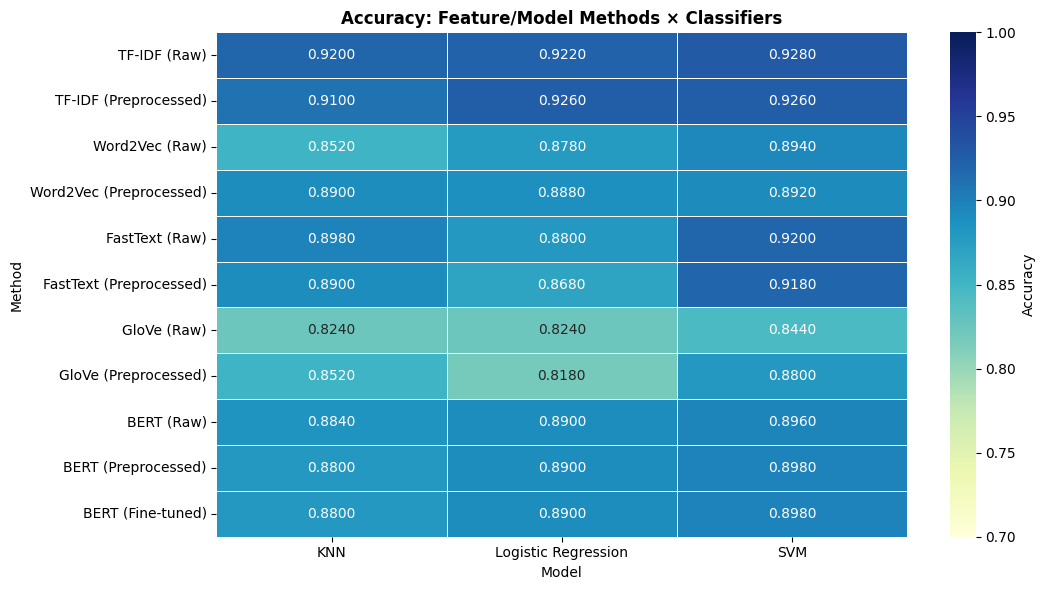

In [38]:
plt.figure(figsize=(11, 6))
sns.heatmap(
    accuracy_df,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Accuracy'},
    vmin=0.70,
    vmax=1.00,
    linewidths=0.5,
    linecolor='white',
)
plt.title('Accuracy: Feature/Model Methods × Classifiers', fontsize=12, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Method')
plt.tight_layout()
plt.show()

/var/folders/ns/q0tvr3b54bjdhrw617073pmc0000gn/T/ipykernel_83873/419960464.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


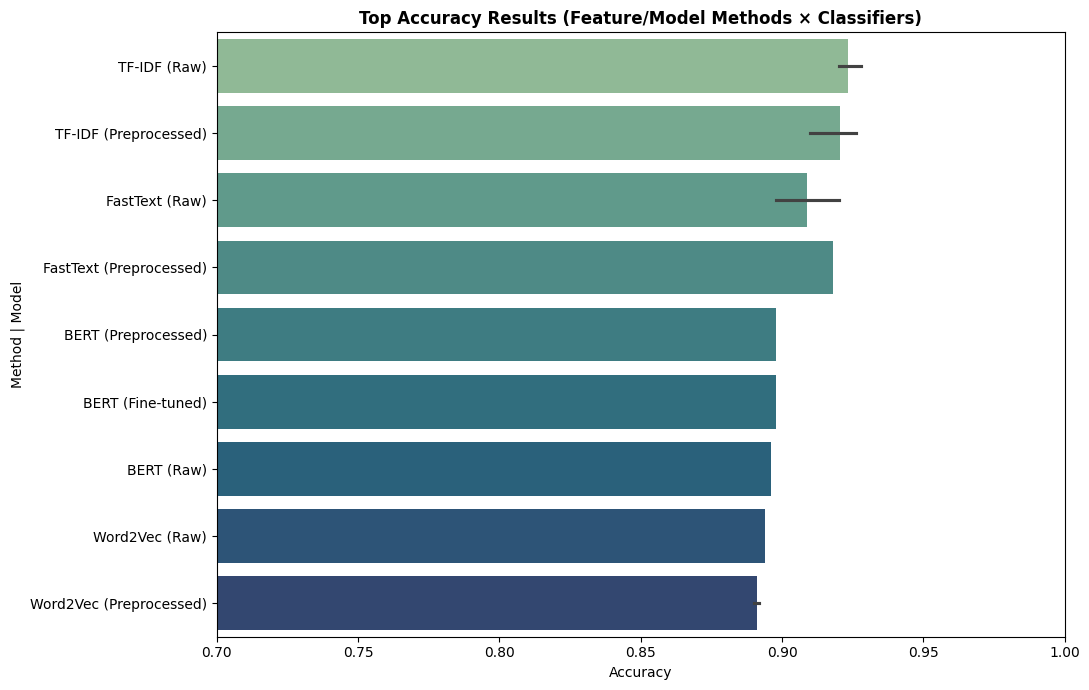

In [39]:
top_k = min(15, len(results_df))
top_results = results_df.nlargest(top_k, 'Accuracy')

plt.figure(figsize=(11, 7))
sns.barplot(
    data=top_results,
    x='Accuracy',
    y='Method',
    orient='h',
    palette='crest',
)
plt.title('Top Accuracy Results (Feature/Model Methods × Classifiers)', fontsize=12, fontweight='bold')
plt.xlabel('Accuracy')
plt.ylabel('Method | Model')
plt.xlim(0.70, 1.00)
plt.tight_layout()
plt.show()

In [40]:
ranking_df = results_df.sort_values(
    by=['Accuracy'],
    ascending=False,
 ).reset_index(drop=True)

ranking_df['Rank'] = np.arange(1, len(ranking_df) + 1)
ranking_df = ranking_df[['Rank', 'Method', 'Model', 'Accuracy']]

ranking_df.head(15)

,Rank,Method,Model,Accuracy
0,1,TF-IDF (Raw),SVM,0.928
1,2,TF-IDF (Preprocessed),SVM,0.926
2,3,TF-IDF (Preprocessed),Logistic Regression,0.926
3,4,TF-IDF (Raw),Logistic Regression,0.922
4,5,TF-IDF (Raw),KNN,0.920
5,6,FastText (Raw),SVM,0.920
6,7,FastText (Preprocessed),SVM,0.918
7,8,TF-IDF (Preprocessed),KNN,0.910
8,9,BERT (Preprocessed),SVM,0.898
9,10,FastText (Raw),KNN,0.898


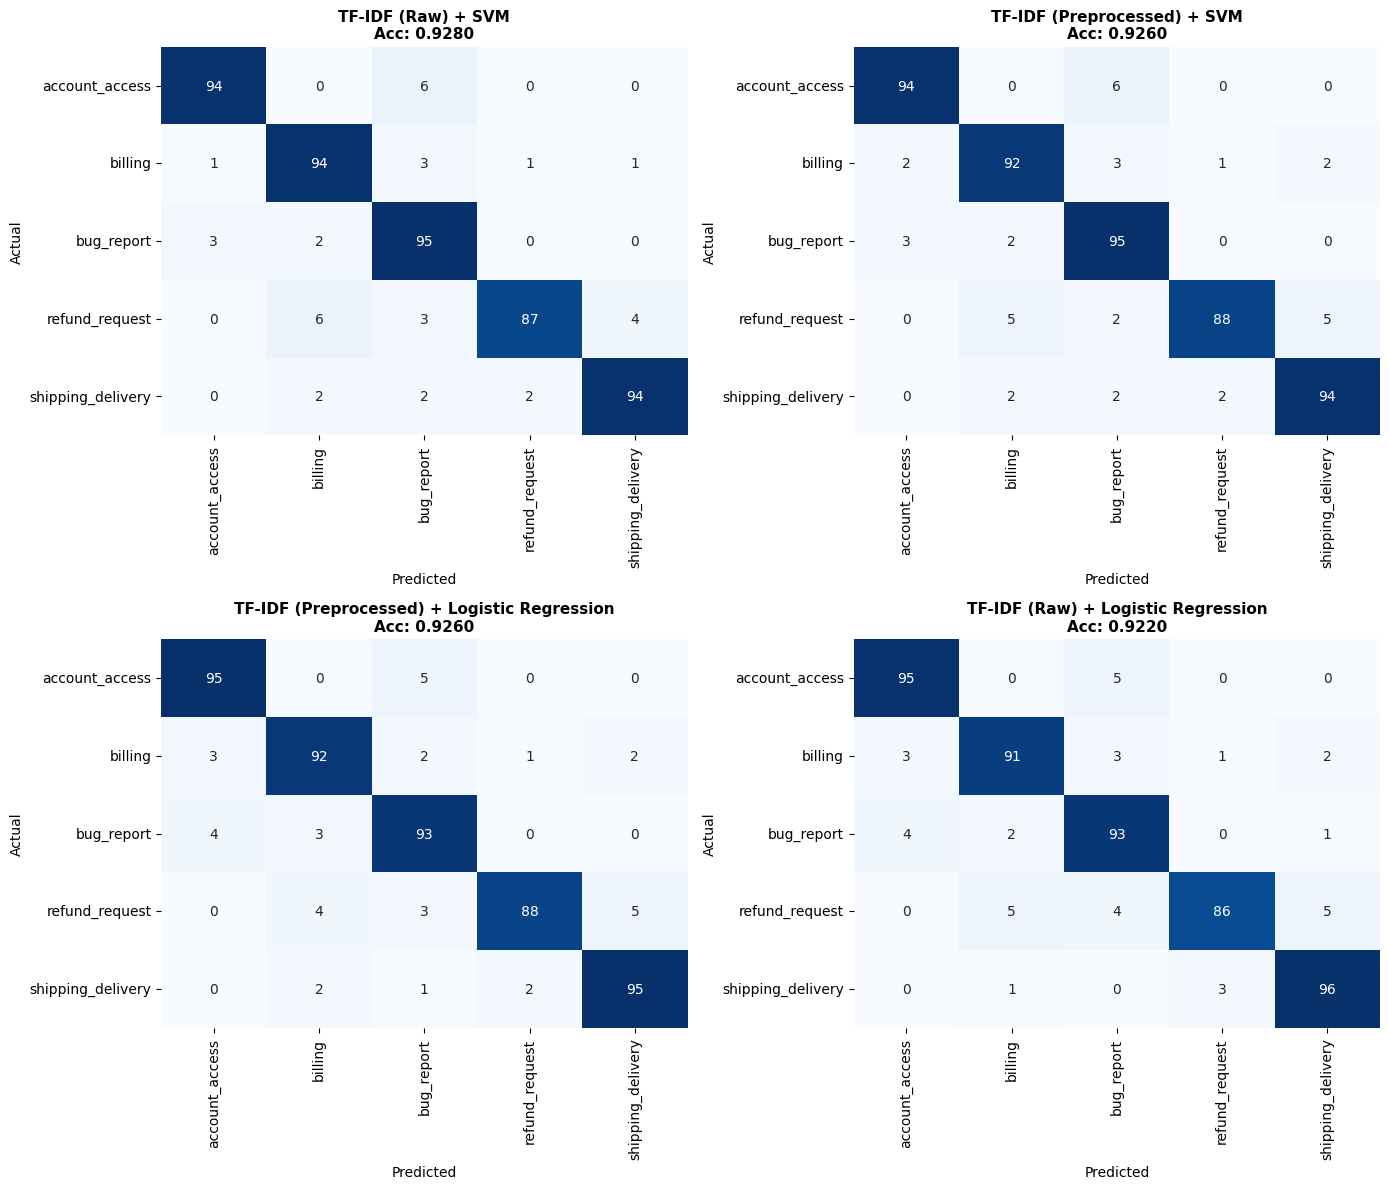

In [41]:
def get_classical_predictions(model_name, X_train_features, X_test_features):
    if model_name == 'SVM':
        clf = SVC(kernel='rbf')
    elif model_name == 'Logistic Regression':
        clf = LogisticRegression(max_iter=1000)
    else:
        clf = KNeighborsClassifier(n_neighbors=5)

    clf.fit(X_train_features, y_train)
    return clf.predict(X_test_features)

feature_model_map = {
    'TF-IDF (Preprocessed)': (X_train_tfidf_prep, X_test_tfidf_prep),
    'TF-IDF (Raw)': (X_train_tfidf_raw, X_test_tfidf_raw),
    'Word2Vec (Preprocessed)': (X_train_embed_prep, X_test_embed_prep),
    'Word2Vec (Raw)': (X_train_embed_raw, X_test_embed_raw),
    'FastText (Preprocessed)': (X_train_embed_ft_prep, X_test_embed_ft_prep),
    'FastText (Raw)': (X_train_embed_ft_raw, X_test_embed_ft_raw),
    'GloVe (Preprocessed)': (X_train_glove_prep, X_test_glove_prep),
    'GloVe (Raw)': (X_train_glove_raw, X_test_glove_raw),
    'BERT (Preprocessed)': (X_train_embed_bert_prep, X_test_embed_bert_prep),
    'BERT (Raw)': (X_train_embed_bert_raw, X_test_embed_bert_raw),
}

top_models = ranking_df.head(4)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for plot_idx, (_, row) in enumerate(top_models.iterrows()):
    method_name = row['Method']
    model_name = row['Model']
    accuracy = row['Accuracy']

    if method_name == 'BERT (Fine-tuned)' and model_name == 'BERT':
        y_pred = bert_test_preds
    else:
        X_train_features, X_test_features = feature_model_map[method_name]
        y_pred = get_classical_predictions(model_name, X_train_features, X_test_features)

    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[plot_idx],
        xticklabels=unique_labels,
        yticklabels=unique_labels,
        cbar=False,
    )
    axes[plot_idx].set_title(
        f"{method_name} + {model_name}\nAcc: {accuracy:.4f}",
        fontsize=11,
        fontweight='bold',
    )
    axes[plot_idx].set_xlabel('Predicted')
    axes[plot_idx].set_ylabel('Actual')

for idx in range(len(top_models), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()